# PXR Phase-1 Post-Mortem -- pm02: The Activity Axis
## *"Were we missing the LOW or the HIGH activity side?"*

Phase 1 of the OpenADMET PXR blind challenge has closed and **253 of the 513**
test compounds were unblinded with their true pEC50. We have cached predictions
from ~344 models/notebooks assembled into a read-only substrate. This notebook
answers the single most important diagnostic question for Phase 2:

> **When our models were wrong, were they wrong about the *inactive* compounds
> (the low-activity tail) or about the *active* compounds (the high-activity
> tail, the actual hits we care about)?**

The answer dictates where Phase-2 effort should go. If we are blind to the
**high** side we are missing hits (catastrophic for a screening campaign). If we
are blind to the **low** side we are flagging dead compounds as active (wasted
follow-up). The short version, derived below: **we miss BOTH tails, but the
inactive (low) tail is ~2.4x worse in absolute error.** The dominant failure is
**over-predicting true inactives** -- the model says "you look ~50% similar to my
actives, so you are active," but they are dead.

### The two questions, made precise
1. **Direction of bias by activity level.** For each truth bin, is the mean
   signed residual `pred - truth` positive (over-predict) or negative
   (under-predict)? How large?
2. **Tail recall.** Of the 42 true actives (truth >= 5.5), what fraction does the
   best model recover as active? Of the 37 true inactives (truth < 3.5), what
   fraction does it recover as inactive?

Everything below is computed on the **253 unblinded compounds** against truth.

In [1]:
import os, sys, json, warnings; warnings.filterwarnings("ignore")
d=os.getcwd()
while not os.path.isdir(os.path.join(d,"data","processed","postmortem")) and os.path.dirname(d)!=d: d=os.path.dirname(d)
os.chdir(d); sys.path.insert(0,"src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pxr.eval import rae
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":110,"font.size":10}); sns.set_style("whitegrid")
PM="data/processed/postmortem"

## Load the substrate
- `cu` -- 253 unblind compounds (chem + truth + consensus). Row order is aligned
  to the prediction/residual matrices.
- `meta` -- 343 models with per-bin bias/MAE already computed.
- `P` / `R` -- (253 x 334) prediction and residual matrices (`R = pred - truth`).
- `y` -- the 253 truths (same order as `cu.truth`).

Bins (fixed for the whole post-mortem): **low** = truth < 3.5 (n=37, inactives),
**mid** = 3.5..5.5 (n=174, the populated middle), **high** = truth >= 5.5 (n=42,
the actives / hits).

In [2]:
cu   = pd.read_parquet(PM+"/pm_compounds.parquet")
meta = pd.read_parquet(PM+"/pm_model_meta.parquet")
P    = np.load(PM+"/pm_pred_unblind.npy")
R    = np.load(PM+"/pm_resid_unblind.npy")
y    = np.load(PM+"/pm_unblind_y.npy")
names= open(PM+"/pm_model_names.txt").read().split()
META = json.load(open(PM+"/pm_meta.json"))

truth = cu["truth"].values
cp    = cu["consensus_pred"].values
assert np.allclose(truth, y), "row order mismatch"

# canonical bin masks
LO = truth < 3.5
HI = truth >= 5.5
MID = ~LO & ~HI
n_lo, n_mid, n_hi = LO.sum(), MID.sum(), HI.sum()

# colorblind-safe palette: inactive=orange, mid=gray, active=teal/blue
C_LOW, C_MID, C_HIGH = "#D55E00", "#999999", "#0072B2"

print(f"253 compounds | truth mean {truth.mean():.2f}  std {truth.std():.2f}  "
      f"range [{truth.min():.2f}, {truth.max():.2f}]")
print(f"bins:  low(<3.5) n={n_lo}   mid(3.5-5.5) n={n_mid}   high(>=5.5) n={n_hi}")
print(f"consensus pred range [{cp.min():.2f}, {cp.max():.2f}]  (truth range "
      f"[{truth.min():.2f}, {truth.max():.2f}])")

253 compounds | truth mean 4.66  std 1.03  range [1.75, 6.72]
bins:  low(<3.5) n=37   mid(3.5-5.5) n=174   high(>=5.5) n=42
consensus pred range [2.43, 5.86]  (truth range [1.75, 6.72])


## Are the 253 unblind compounds representative of all 513?
Before trusting any conclusion, confirm the unblind subset is not a weird slice.
We compare the unblind 253 against the held-back 260 on the chemistry axes we
have for all 513 (we have no truth for the held-back set, so we compare
*chemistry*, not activity). If the distributions match, the activity-axis
lessons below should generalize to the remaining 260.

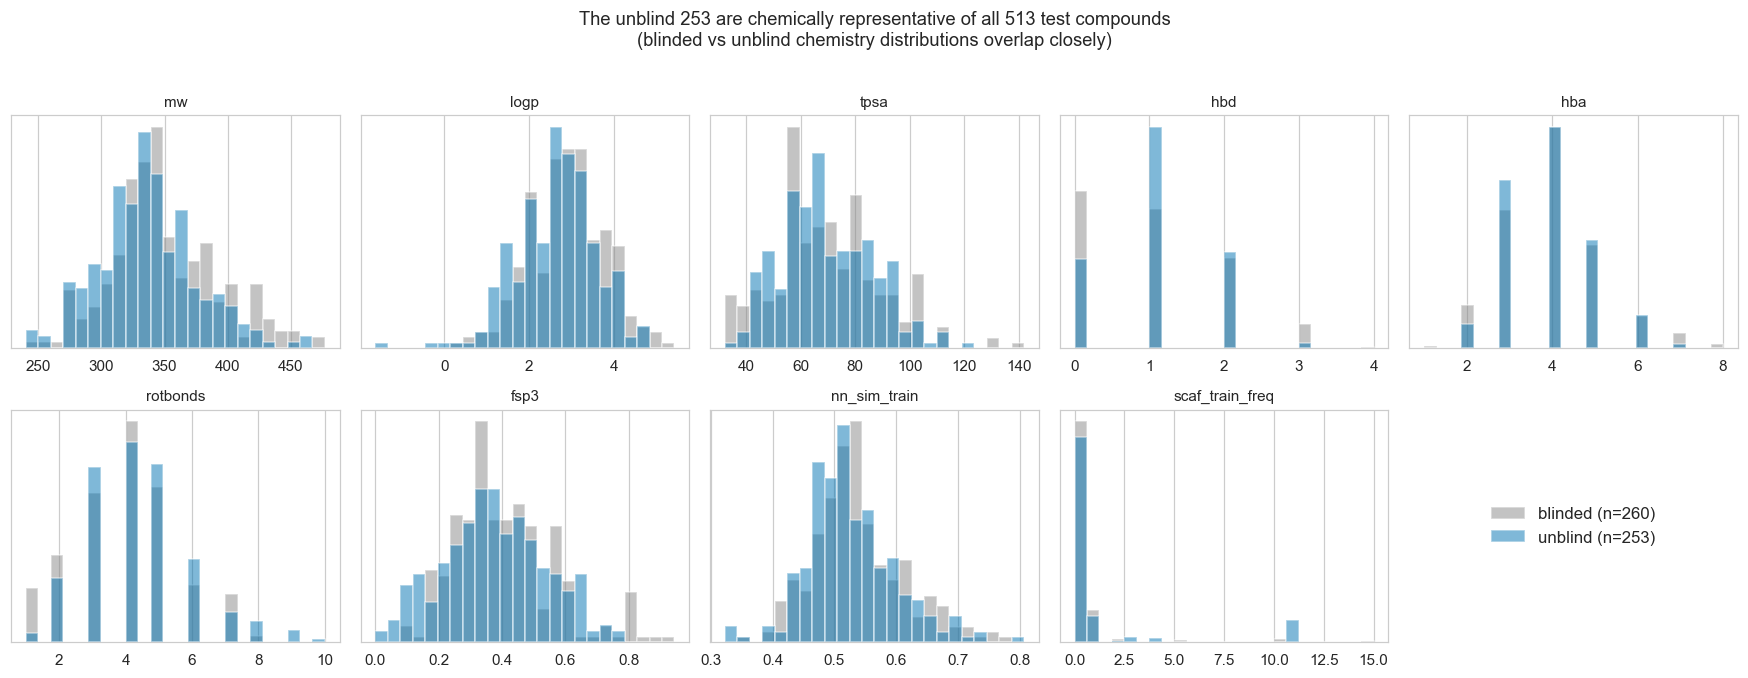

median nn_sim_train  unblind 0.515   blinded 0.530
frac novel scaffold  unblind 0.78   blinded 0.84


In [3]:
all513 = pd.read_parquet(PM+"/pm_test_chem_all513.parquet")
un = all513[all513["is_unblind"]]
bl = all513[~all513["is_unblind"]]
chem_cols = ["mw","logp","tpsa","hbd","hba","rotbonds","fsp3","nn_sim_train","scaf_train_freq"]

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axes.ravel(), chem_cols):
    lo = min(all513[col].min(), all513[col].min())
    hi = all513[col].max()
    bins = np.linspace(lo, hi, 25)
    ax.hist(bl[col], bins=bins, density=True, alpha=0.5, color="#888888", label=f"blinded (n={len(bl)})")
    ax.hist(un[col], bins=bins, density=True, alpha=0.5, color="#0072B2", label=f"unblind (n={len(un)})")
    ax.set_title(col, fontsize=10)
    ax.set_yticks([])
axes.ravel()[-1].axis("off")
h, l = axes[0,0].get_legend_handles_labels()
axes.ravel()[-1].legend(h, l, loc="center", fontsize=11, frameon=False)
fig.suptitle("The unblind 253 are chemically representative of all 513 test compounds\n"
             "(blinded vs unblind chemistry distributions overlap closely)", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

# quick numeric sanity
print("median nn_sim_train  unblind %.3f   blinded %.3f" % (un.nn_sim_train.median(), bl.nn_sim_train.median()))
print("frac novel scaffold  unblind %.2f   blinded %.2f" % ((un.scaf_train_freq==0).mean(), (bl.scaf_train_freq==0).mean()))

**Lesson.** The unblind and blinded halves overlap on every chemistry axis,
including the two that matter most for difficulty -- nearest-neighbour similarity
to train (`nn_sim_train`, median ~0.51 in both) and scaffold novelty (~70% novel
scaffolds in both). So the activity-axis failures we diagnose on the 253 are a
faithful preview of the held-back 260.

## Figure 1 -- Consensus calibration: the classic regression-to-the-mean fan
This is the master diagnostic. **x = true pEC50, y = consensus prediction**
(mean over the 71 legit models, RAE < 0.72). We overlay:
- the **y = x** identity (perfect calibration),
- a **binned-mean curve** (truth deciles) -- the empirical calibration,
- a **fitted regression line** `pred = a + b*truth`.

If the model were calibrated, points would hug y=x and the binned curve would
lie on it. Instead the cloud is **flattened**: at low truth the prediction sits
far *above* y=x, at high truth it sits *below*. The compounds get squeezed toward
the populated middle (~4.7). That squeeze is **variance compression** and it is
the single mechanism behind every number in this notebook.

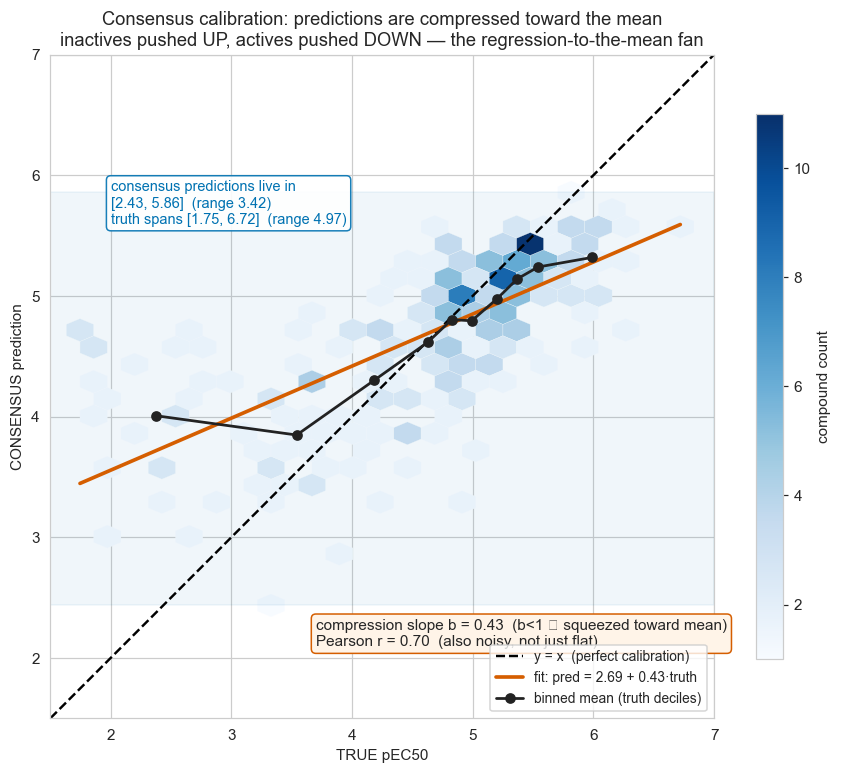

pred~truth slope b=0.431  (compression);  Pearson r=0.698


In [4]:
# regression of consensus pred on truth (b<1 => compression)
b, a = np.polyfit(truth, cp, 1)
corr = np.corrcoef(truth, cp)[0,1]
# binned-mean calibration curve over deciles of truth
qe = np.quantile(truth, np.linspace(0,1,11))
qe[-1]+=1e-6
dig = np.clip(np.digitize(truth, qe[1:-1]), 0, 9)
bx = np.array([truth[dig==k].mean() for k in range(10)])
by = np.array([cp[dig==k].mean() for k in range(10)])

fig, ax = plt.subplots(figsize=(8.2, 7))
hb = ax.hexbin(truth, cp, gridsize=22, cmap="Blues", mincnt=1, linewidths=0.2, edgecolors="white")
cb = fig.colorbar(hb, ax=ax, shrink=0.8); cb.set_label("compound count")
lim = [1.5, 7.0]
ax.plot(lim, lim, "k--", lw=1.6, label="y = x  (perfect calibration)")
xs = np.linspace(truth.min(), truth.max(), 50)
ax.plot(xs, a + b*xs, color="#D55E00", lw=2.4, label=f"fit: pred = {a:.2f} + {b:.2f}·truth")
ax.plot(bx, by, "o-", color="#222222", lw=1.8, ms=6, label="binned mean (truth deciles)")
# shade the compressed prediction band
ax.axhspan(cp.min(), cp.max(), color="#0072B2", alpha=0.06)
ax.annotate(f"consensus predictions live in\n[{cp.min():.2f}, {cp.max():.2f}]  (range {cp.max()-cp.min():.2f})\n"
            f"truth spans [{truth.min():.2f}, {truth.max():.2f}]  (range {truth.max()-truth.min():.2f})",
            xy=(2.0, 5.6), fontsize=9.5, color="#0072B2",
            bbox=dict(boxstyle="round", fc="white", ec="#0072B2", alpha=0.9))
ax.annotate("compression slope b = %.2f  (b<1 ⇒ squeezed toward mean)\nPearson r = %.2f  (also noisy, not just flat)"
            % (b, corr), xy=(3.7, 2.1), fontsize=10,
            bbox=dict(boxstyle="round", fc="#FFF4E8", ec="#D55E00"))
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
ax.set_xlabel("TRUE pEC50"); ax.set_ylabel("CONSENSUS prediction")
ax.set_title("Consensus calibration: predictions are compressed toward the mean\n"
             "inactives pushed UP, actives pushed DOWN — the regression-to-the-mean fan")
ax.legend(loc="lower right", fontsize=9); plt.tight_layout(); plt.show()
print(f"pred~truth slope b={b:.3f}  (compression);  Pearson r={corr:.3f}")

**Lesson.** The fitted slope `b = 0.43` (well below 1) is the compression
signature: a one-unit change in true activity moves the prediction less than half
a unit. The black binned curve crosses y=x only near the data center (~4.7) and
diverges at both ends. And note `r = 0.70`: predictions are not only compressed,
they are *noisy* about that compressed line. The model has collapsed a 5-log
dynamic range into a ~3.4-log prediction band.

## Figure 2 -- Signed residual by truth: the asymmetry, made unmistakable
The calibration fan tells us *that* there is bias; this panel tells us *which
direction and how much*, bin by bin. **Left:** mean signed residual
`pred - truth` in each truth decile, with 95% CI error bars and a zero line.
Positive = over-predict (call dead compounds active), negative = under-predict
(miss real actives). **Right:** the same in the three canonical bins, with MAE
overlaid so the magnitudes are explicit.

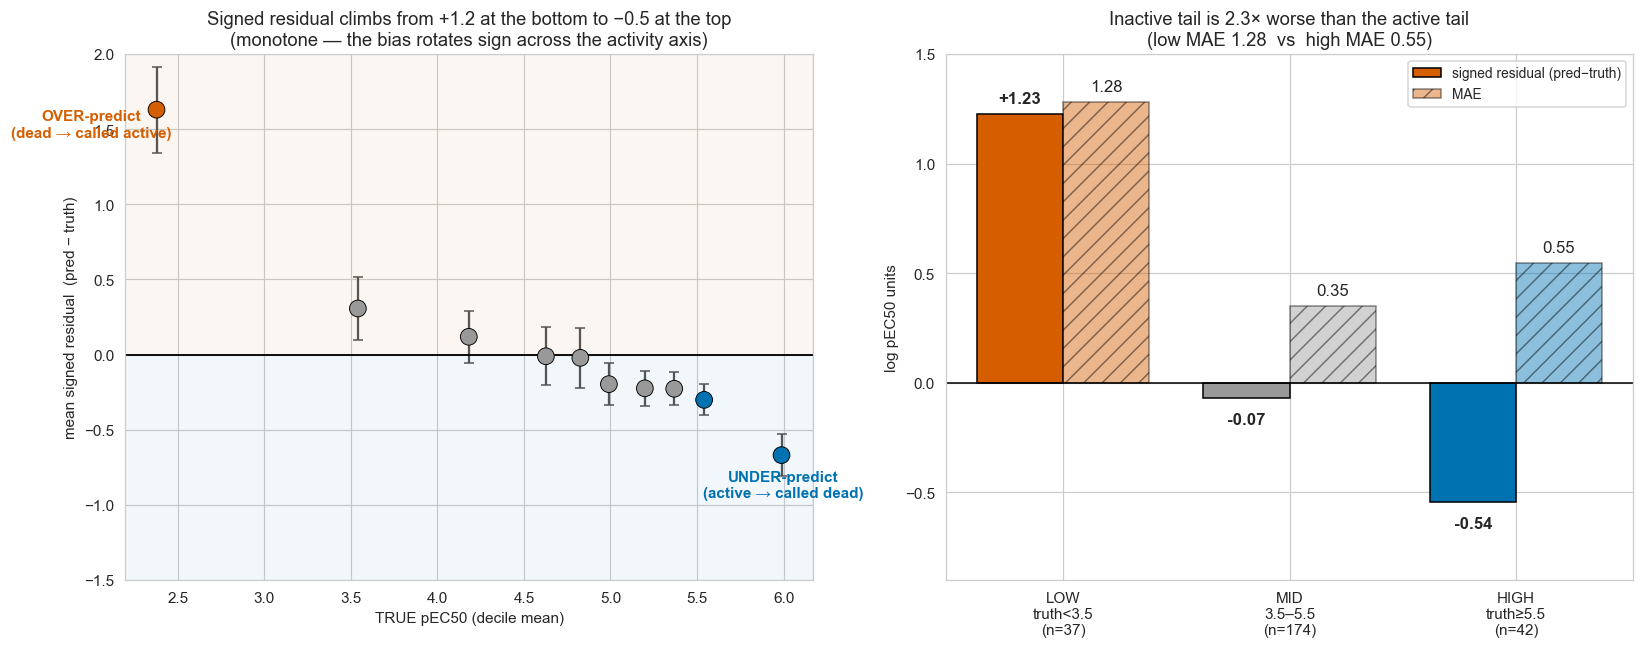

signed bias  low +1.23  mid -0.07  high -0.54
MAE          low  1.28  mid  0.35  high  0.55
low/high MAE ratio = 2.34


In [5]:
resid = cp - truth
# decile signed residual
dmean = np.array([resid[dig==k].mean() for k in range(10)])
dsem  = np.array([resid[dig==k].std()/max(1,np.sqrt((dig==k).sum())) for k in range(10)])
dx    = bx

bias = {"low": resid[LO].mean(), "mid": resid[MID].mean(), "high": resid[HI].mean()}
mae  = {"low": np.abs(resid[LO]).mean(), "mid": np.abs(resid[MID]).mean(), "high": np.abs(resid[HI]).mean()}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6))

# left: decile signed residual
cols = [C_LOW if x<3.5 else (C_HIGH if x>=5.5 else C_MID) for x in dx]
axL.axhline(0, color="k", lw=1.2)
axL.errorbar(dx, dmean, yerr=1.96*dsem, fmt="none", ecolor="#555", capsize=3, zorder=1)
axL.scatter(dx, dmean, c=cols, s=120, zorder=3, edgecolors="k", linewidths=0.6)
axL.axhspan(0, 3, color=C_LOW, alpha=0.05); axL.axhspan(-3, 0, color=C_HIGH, alpha=0.05)
axL.text(2.0, 1.45, "OVER-predict\n(dead → called active)", color=C_LOW, fontsize=10, ha="center", fontweight="bold")
axL.text(6.0, -0.95, "UNDER-predict\n(active → called dead)", color=C_HIGH, fontsize=10, ha="center", fontweight="bold")
axL.set_ylim(-1.5, 2.0)
axL.set_xlabel("TRUE pEC50 (decile mean)"); axL.set_ylabel("mean signed residual  (pred − truth)")
axL.set_title("Signed residual climbs from +1.2 at the bottom to −0.5 at the top\n"
              "(monotone — the bias rotates sign across the activity axis)")

# right: 3-bin signed residual + MAE
xb = np.arange(3); w=0.38
sb = [bias["low"], bias["mid"], bias["high"]]
mb = [mae["low"], mae["mid"], mae["high"]]
barcols=[C_LOW, C_MID, C_HIGH]
b1=axR.bar(xb-w/2, sb, w, color=barcols, edgecolor="k", label="signed residual (pred−truth)")
b2=axR.bar(xb+w/2, mb, w, color=barcols, alpha=0.45, hatch="//", edgecolor="k", label="MAE")
axR.axhline(0, color="k", lw=1)
for xi,(s,m) in enumerate(zip(sb,mb)):
    axR.text(xi-w/2, s+(0.05 if s>=0 else -0.12), f"{s:+.2f}", ha="center", fontsize=11, fontweight="bold")
    axR.text(xi+w/2, m+0.05, f"{m:.2f}", ha="center", fontsize=11)
axR.set_xticks(xb); axR.set_xticklabels([f"LOW\ntruth<3.5\n(n={n_lo})",
                                         f"MID\n3.5–5.5\n(n={n_mid})",
                                         f"HIGH\ntruth≥5.5\n(n={n_hi})"])
axR.set_ylabel("log pEC50 units"); axR.set_ylim(-0.9, 1.5)
axR.set_title(f"Inactive tail is {mae['low']/mae['high']:.1f}× worse than the active tail\n"
              f"(low MAE {mae['low']:.2f}  vs  high MAE {mae['high']:.2f})")
axR.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

print("signed bias  low %+.2f  mid %+.2f  high %+.2f" % (bias["low"], bias["mid"], bias["high"]))
print("MAE          low  %.2f  mid  %.2f  high  %.2f" % (mae["low"], mae["mid"], mae["high"]))
print("low/high MAE ratio = %.2f" % (mae["low"]/mae["high"]))

**Lesson — the headline answer.** The bias *rotates sign* across the activity
axis: **+1.23 on the inactives, ~0 in the middle, −0.54 on the actives.** We miss
**both** sides, but not equally:
- **LOW side (inactives):** MAE **1.28** — we systematically over-call dead
  compounds as moderately active.
- **HIGH side (actives):** MAE **0.55** — we under-call real hits, but less
  severely.

The inactive tail is **~2.3× worse**. So to the user's question: *we missed the
LOW (inactive) side more.* The mechanism is the same compression — but because
train has very few true inactives and very few hits, the squeeze toward the
populated middle (~4.7) is *longer* on the inactive end (true ~1.8 → pred ~4.6 is
a 2.8-unit lift) than on the active end (true ~6.7 → pred ~5.5 is a 1.2-unit
drop).

## Figure 3 -- This is NOT a consensus artifact: every model does it
A skeptic could say "the consensus averages models and averaging causes
compression." So we check the **individual models** directly. Using the
pre-computed `bias_low` and `bias_high` from `meta` for the **71 legit models**
(te_unblind_rae < 0.72), we plot the distribution of each model's low-bin bias
and high-bin bias. If the two-sided bias is universal, *essentially every* legit
model should sit at bias_low > 0 and bias_high < 0.

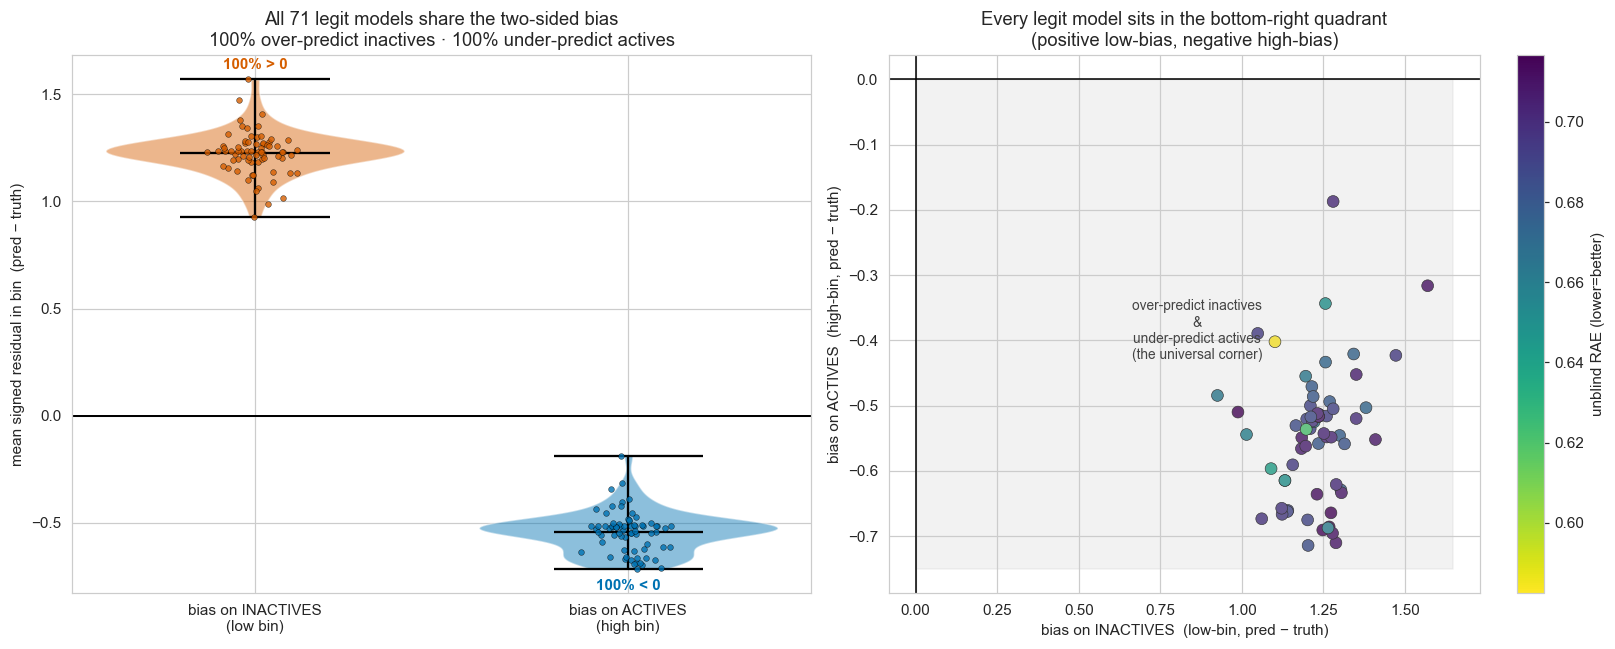

legit models n=71  |  frac over-predict inactives = 1.00  |  frac under-predict actives = 1.00


In [6]:
leg = meta[meta["te_unblind_rae"] < 0.72].copy()
frac_over_low  = (leg["bias_low"]  > 0).mean()
frac_under_high= (leg["bias_high"] < 0).mean()

fig, (axA, axB) = plt.subplots(1, 2, figsize=(15, 6))

# A: paired violins of bias_low and bias_high
data = [leg["bias_low"].values, leg["bias_high"].values]
parts = axA.violinplot(data, positions=[0,1], showmeans=True, widths=0.8)
for pc, c in zip(parts["bodies"], [C_LOW, C_HIGH]):
    pc.set_facecolor(c); pc.set_alpha(0.45)
for k in ("cbars","cmins","cmaxes","cmeans"):
    parts[k].set_edgecolor("k")
# jittered points
for i,(arr,c) in enumerate(zip(data,[C_LOW,C_HIGH])):
    axA.scatter(np.random.RandomState(0).normal(i,0.05,len(arr)), arr, s=14, color=c, edgecolors="k", linewidths=0.3, alpha=0.8, zorder=3)
axA.axhline(0, color="k", lw=1.3)
axA.set_xticks([0,1]); axA.set_xticklabels([f"bias on INACTIVES\n(low bin)", f"bias on ACTIVES\n(high bin)"])
axA.set_ylabel("mean signed residual in bin  (pred − truth)")
axA.set_title(f"All {len(leg)} legit models share the two-sided bias\n"
              f"{frac_over_low*100:.0f}% over-predict inactives · {frac_under_high*100:.0f}% under-predict actives")
axA.text(0, leg["bias_low"].max()+0.05, f"{frac_over_low*100:.0f}% > 0", ha="center", color=C_LOW, fontweight="bold")
axA.text(1, leg["bias_high"].min()-0.10, f"{frac_under_high*100:.0f}% < 0", ha="center", color=C_HIGH, fontweight="bold")

# B: scatter bias_low vs bias_high, colored by RAE
sc = axB.scatter(leg["bias_low"], leg["bias_high"], c=leg["te_unblind_rae"], cmap="viridis_r", s=60, edgecolors="k", linewidths=0.4)
cb = fig.colorbar(sc, ax=axB); cb.set_label("unblind RAE (lower=better)")
axB.axhline(0, color="k", lw=1); axB.axvline(0, color="k", lw=1)
axB.fill_between([0, leg["bias_low"].max()*1.05], 0, leg["bias_high"].min()*1.05,
                 color="#cccccc", alpha=0.25)
axB.text(leg["bias_low"].max()*0.55, leg["bias_high"].min()*0.6,
         "over-predict inactives\n&\nunder-predict actives\n(the universal corner)",
         ha="center", fontsize=9, color="#444")
axB.set_xlabel("bias on INACTIVES  (low-bin, pred − truth)")
axB.set_ylabel("bias on ACTIVES  (high-bin, pred − truth)")
axB.set_title("Every legit model sits in the bottom-right quadrant\n(positive low-bias, negative high-bias)")
plt.tight_layout(); plt.show()

print(f"legit models n={len(leg)}  |  frac over-predict inactives = {frac_over_low:.2f}  "
      f"|  frac under-predict actives = {frac_under_high:.2f}")

**Lesson.** The two-sided bias is **structural, not a consensus artifact**:
**100% of legit models over-predict the inactives and 100% under-predict the
actives.** Coloring by RAE shows even the *best* models live in that same corner
— being a good model does not buy you out of the tail bias; it only shrinks the
noise. Phase-2 corrections must be **tail-aware**; no amount of re-blending the
same compressed predictors escapes the quadrant.

## Figure 4 -- Quantifying the compression: per-model slope and prediction range
Two complementary views of the squeeze across all 334 in-matrix models:
- **Calibration slope** `b` from the substrate's definition (truth ~ a + b·pred;
  b < 1 ⇒ compression). Median ≈ 0.98 *looks* fine — but slope alone hides the
  problem because it is paired with low correlation.
- **Prediction dynamic range** (max − min of each model's predictions on the 253)
  vs the true range (4.98). A model whose predictions span far less than 4.98 is
  compressing regardless of its slope.

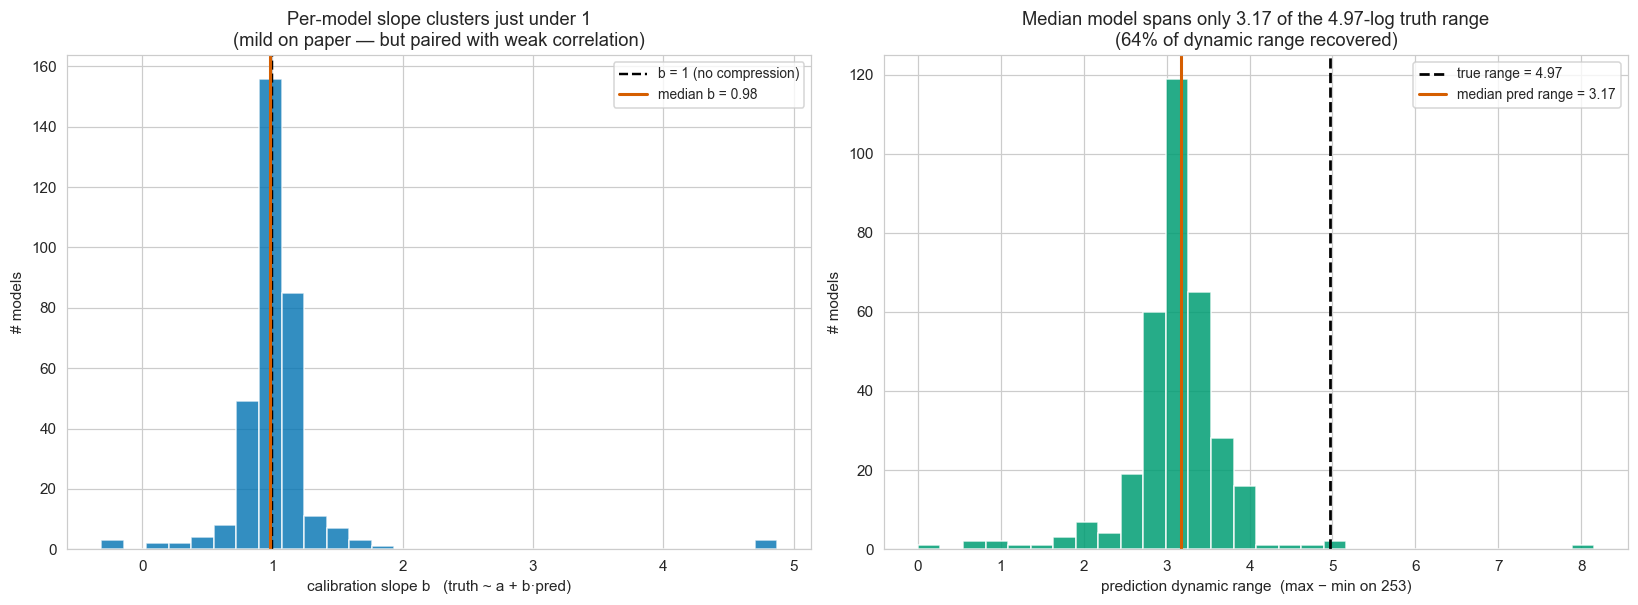

median slope 0.981 | median pred range 3.17 vs truth range 4.97 | median pred_std 0.617 vs truth_std 1.032


In [7]:
rng_model = P.max(0) - P.min(0)               # per-model pred range (334,)
slope = meta.set_index("name").loc[names, "slope"].values  # align to matrix col order
pred_std_model = P.std(0)
truth_range = truth.max() - truth.min()

fig, (axA, axB) = plt.subplots(1, 2, figsize=(15, 5.6))

axA.hist(slope, bins=30, color="#0072B2", alpha=0.8, edgecolor="white")
axA.axvline(1.0, color="k", ls="--", lw=1.6, label="b = 1 (no compression)")
axA.axvline(np.median(slope), color="#D55E00", lw=2, label=f"median b = {np.median(slope):.2f}")
axA.set_xlabel("calibration slope b   (truth ~ a + b·pred)"); axA.set_ylabel("# models")
axA.set_title("Per-model slope clusters just under 1\n(mild on paper — but paired with weak correlation)")
axA.legend(fontsize=9)

axB.hist(rng_model, bins=30, color="#009E73", alpha=0.85, edgecolor="white")
axB.axvline(truth_range, color="k", ls="--", lw=1.8, label=f"true range = {truth_range:.2f}")
axB.axvline(np.median(rng_model), color="#D55E00", lw=2, label=f"median pred range = {np.median(rng_model):.2f}")
axB.set_xlabel("prediction dynamic range  (max − min on 253)"); axB.set_ylabel("# models")
axB.set_title(f"Median model spans only {np.median(rng_model):.2f} of the {truth_range:.2f}-log truth range\n"
              f"({np.median(rng_model)/truth_range*100:.0f}% of dynamic range recovered)")
axB.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"median slope {np.median(slope):.3f} | median pred range {np.median(rng_model):.2f} "
      f"vs truth range {truth_range:.2f} | median pred_std {np.median(pred_std_model):.3f} vs truth_std {truth.std():.3f}")

**Lesson.** This is the subtle part. The median *slope* (0.98) is reassuringly
near 1, which is why slope alone fooled earlier blend-tuning work. But the median
*prediction range* is only ~3.2 of the 4.98-log truth range (~64%), and median
pred_std (0.62) is ~60% of truth_std (1.03). The reconciliation: the predictions
are scattered *noisily* around a near-unit-slope line, so OLS slope stays ~1
while the actual spread is far too narrow at the tails. **Compression here is a
variance + noise problem, not a pure scale problem** — which is exactly why a
single scalar "rank-stretch" only recovers a few thousandths of RAE.

## Figure 5 -- Recall of the tails (the operational question)
A drug-discovery campaign cares about *classification at the threshold*, not just
regression error. So we ask: of the **42 true actives** (truth >= 5.5), what
fraction does the model *predict* as active (>= 5.5, and the looser >= 5.0)? Of
the **37 true inactives** (truth < 3.5), what fraction does it predict as
inactive (< 3.5, and the looser < 4.0)? We compare the **best single model**
(`oof_nb390_pcs_iso`, structure3D) against the **consensus**.

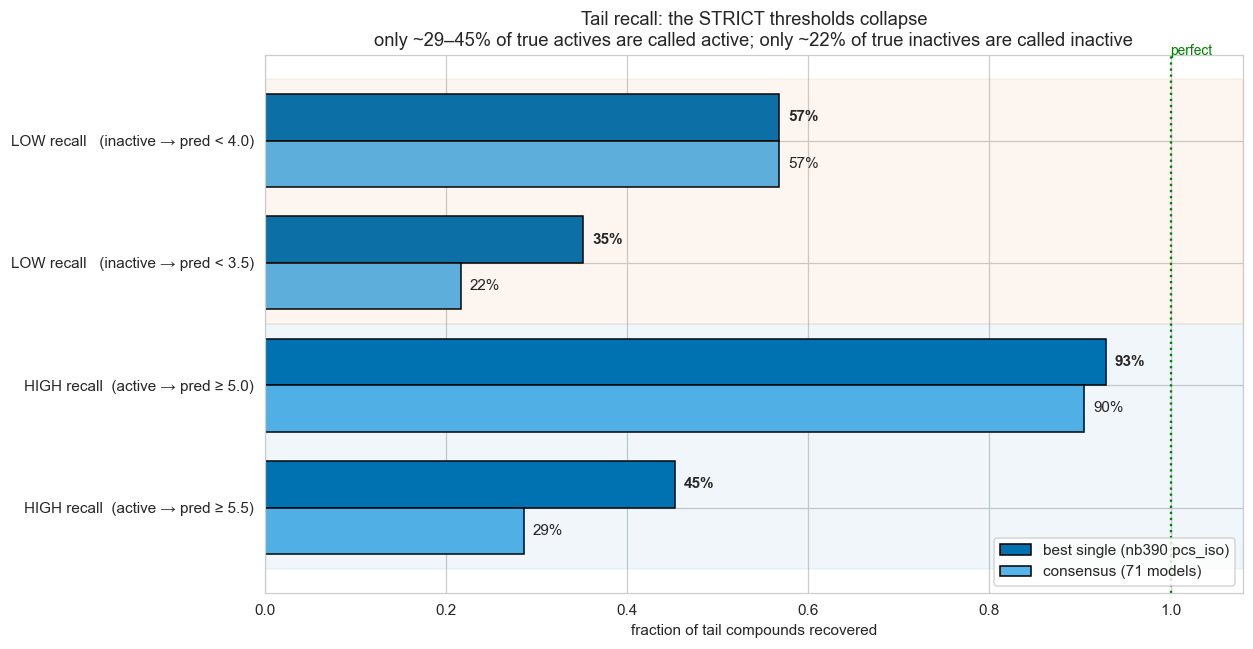

HIGH≥5.5  best 0.45  consensus 0.29
HIGH≥5.0  best 0.93  consensus 0.90
LOW<3.5   best 0.35  consensus 0.22
LOW<4.0   best 0.57  consensus 0.57


In [8]:
c390 = names.index("oof_nb390_pcs_iso")
p390 = P[:, c390]

def recall(pred, mask, thr, side):
    if side == "high":  return (pred[mask] >= thr).mean()
    else:               return (pred[mask] <  thr).mean()

rows = [
    ("HIGH recall  (active → pred ≥ 5.5)", recall(p390,HI,5.5,"high"), recall(cp,HI,5.5,"high")),
    ("HIGH recall  (active → pred ≥ 5.0)", recall(p390,HI,5.0,"high"), recall(cp,HI,5.0,"high")),
    ("LOW recall   (inactive → pred < 3.5)", recall(p390,LO,3.5,"low"), recall(cp,LO,3.5,"low")),
    ("LOW recall   (inactive → pred < 4.0)", recall(p390,LO,4.0,"low"), recall(cp,LO,4.0,"low")),
]
lab = [r[0] for r in rows]; v390=[r[1] for r in rows]; vcon=[r[2] for r in rows]

fig, ax = plt.subplots(figsize=(11.5, 6))
ypos = np.arange(len(rows)); h=0.38
b1=ax.barh(ypos+h/2, v390, h, color="#0072B2", edgecolor="k", label="best single (nb390 pcs_iso)")
b2=ax.barh(ypos-h/2, vcon, h, color="#56B4E9", edgecolor="k", label="consensus (71 models)")
for yi,(a1,a2) in enumerate(zip(v390,vcon)):
    ax.text(a1+0.01, yi+h/2, f"{a1*100:.0f}%", va="center", fontsize=10, fontweight="bold")
    ax.text(a2+0.01, yi-h/2, f"{a2*100:.0f}%", va="center", fontsize=10)
ax.axvline(1.0, color="green", ls=":", lw=1.5); ax.text(1.0, len(rows)-0.3, "perfect", color="green", fontsize=9)
ax.set_yticks(ypos); ax.set_yticklabels(lab)
ax.set_xlim(0,1.08); ax.set_xlabel("fraction of tail compounds recovered")
ax.set_title("Tail recall: the STRICT thresholds collapse\n"
             "only ~29–45% of true actives are called active; only ~22% of true inactives are called inactive")
ax.legend(loc="lower right", fontsize=10)
# shade the catastrophic rows
ax.axhspan(2-0.5, 3+0.5, color=C_LOW, alpha=0.06)
ax.axhspan(-0.5, 1+0.5, color=C_HIGH, alpha=0.06)
plt.tight_layout(); plt.show()

hit_recall_best = recall(p390,HI,5.5,"high")
hit_recall_consensus = recall(cp,HI,5.5,"high")
inactive_recall_consensus = recall(cp,LO,3.5,"low")
print(f"HIGH≥5.5  best {hit_recall_best:.2f}  consensus {hit_recall_consensus:.2f}")
print(f"HIGH≥5.0  best {recall(p390,HI,5.0,'high'):.2f}  consensus {recall(cp,HI,5.0,'high'):.2f}")
print(f"LOW<3.5   best {recall(p390,LO,3.5,'low'):.2f}  consensus {inactive_recall_consensus:.2f}")
print(f"LOW<4.0   best {recall(p390,LO,4.0,'low'):.2f}  consensus {recall(cp,LO,4.0,'low'):.2f}")

**Lesson.** At the *strict* thresholds the tails are barely recovered:
- Only **29% (consensus) / 45% (best)** of true actives clear pred >= 5.5. Loosen
  to >= 5.0 and recall jumps to ~90% — i.e. the actives are pushed *down to the
  4.5–5.0 band*, just under the line. The hits are not invisible; they are
  **demoted to the upper-middle**.
- Only **22%** of true inactives are called inactive (< 3.5); even at < 4.0 it is
  ~57%. The dead compounds are lifted up to the 4–5 band.

Operationally: **a hard 5.5 cutoff would miss most hits**, and a hard 3.5 cutoff
would clear almost no inactives — because compression has herded everything into
the 4–5 zone. A Phase-2 ranking/triage scheme must use *softer*, similarity-aware
thresholds, not the nominal activity cutoffs.

## Figure 6 -- The confusion structure, end to end
One more view tying it together: a 3x3 confusion matrix of **true bin** (rows)
vs **predicted bin** (consensus, columns), so we can see exactly where mass
leaks. The off-diagonal cells are the failures; the **(LOW→MID)** and
**(HIGH→MID)** cells are the compression draining both tails into the middle.

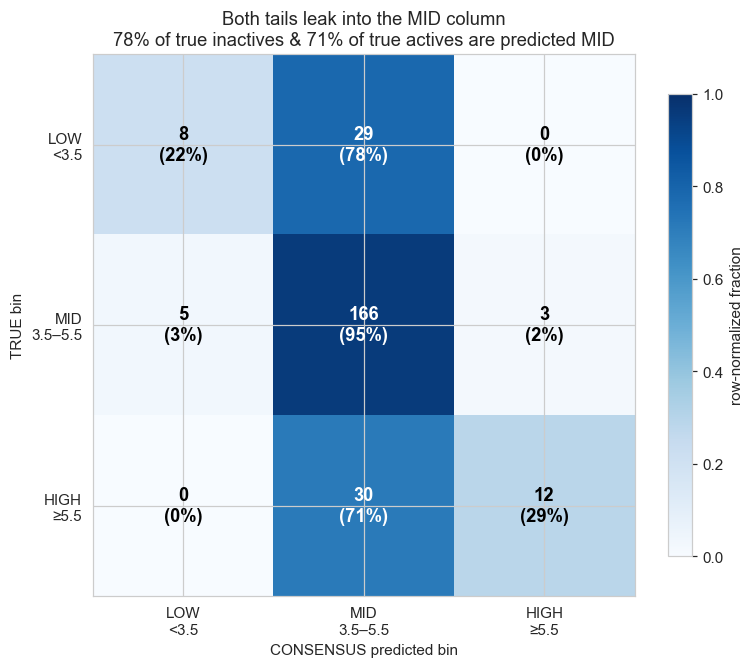

confusion (rows=true, cols=pred):
 [[  8  29   0]
 [  5 166   3]
 [  0  30  12]]


In [9]:
def to_bin(v):
    return np.where(v<3.5, 0, np.where(v>=5.5, 2, 1))
tb = to_bin(truth); pbn = to_bin(cp)
M = np.zeros((3,3), int)
for t,p in zip(tb,pbn): M[t,p]+=1
labels=["LOW\n<3.5","MID\n3.5–5.5","HIGH\n≥5.5"]

fig, ax = plt.subplots(figsize=(7.2, 6.2))
Mn = M / M.sum(1, keepdims=True)
im = ax.imshow(Mn, cmap="Blues", vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        txt = f"{M[i,j]}\n({Mn[i,j]*100:.0f}%)"
        ax.text(j, i, txt, ha="center", va="center",
                color="white" if Mn[i,j]>0.5 else "black", fontsize=12, fontweight="bold")
ax.set_xticks([0,1,2]); ax.set_xticklabels(labels); ax.set_yticks([0,1,2]); ax.set_yticklabels(labels)
ax.set_xlabel("CONSENSUS predicted bin"); ax.set_ylabel("TRUE bin")
ax.set_title("Both tails leak into the MID column\n"
             f"{Mn[0,1]*100:.0f}% of true inactives & {Mn[2,1]*100:.0f}% of true actives are predicted MID")
cb=fig.colorbar(im, ax=ax, shrink=0.8); cb.set_label("row-normalized fraction")
plt.tight_layout(); plt.show()
print("confusion (rows=true, cols=pred):\n", M)

**Lesson.** The diagonal is strong only for the MID bin. **78% of true inactives
and 71% of true actives are predicted as MID** — the tails empty into the center.
The consensus essentially refuses to commit to either extreme.

## Figure 7 -- WHO is missed worst: ranked tables
Names and chemistry of the **top-15 over-predicted** (true low, high pred) and
**top-15 under-predicted** (true high, low pred), ranked by `consensus_resid`.
We carry `nn_sim_train` (max Tanimoto to any train compound) and `scaf_train_freq`
(0 = scaffold never seen in train) to test the hypothesis that the worst misses
are **novel-scaffold, half-similar** compounds.

In [10]:
cols_show = ["name","truth","consensus_pred","consensus_resid","nn_sim_train","scaf_train_freq","mw","logp"]
over15  = cu.sort_values("consensus_resid", ascending=False).head(15)[cols_show].reset_index(drop=True)
under15 = cu.sort_values("consensus_resid").head(15)[cols_show].reset_index(drop=True)

def fmt(df):
    d=df.copy()
    for c in ["truth","consensus_pred","consensus_resid","nn_sim_train","logp"]: d[c]=d[c].round(2)
    d["mw"]=d["mw"].round(0).astype(int)
    d["scaf_train_freq"]=d["scaf_train_freq"].astype(int)
    return d

print("="*92); print("TOP-15 OVER-PREDICTED  (true INACTIVE called active)  — the LOW-side misses")
print("="*92); print(fmt(over15).to_string(index=False))
print()
print("="*92); print("TOP-15 UNDER-PREDICTED  (true ACTIVE called dead)  — the HIGH-side misses")
print("="*92); print(fmt(under15).to_string(index=False))

print()
print("OVER-predicted (n=15): frac novel-scaffold = %.0f%% | median nn_sim_train = %.2f | median |resid| = %.2f"
      % ((over15.scaf_train_freq==0).mean()*100, over15.nn_sim_train.median(), over15.consensus_resid.abs().median()))
print("UNDER-predicted(n=15): frac novel-scaffold = %.0f%% | median nn_sim_train = %.2f | median |resid| = %.2f"
      % ((under15.scaf_train_freq==0).mean()*100, under15.nn_sim_train.median(), under15.consensus_resid.abs().median()))

TOP-15 OVER-PREDICTED  (true INACTIVE called active)  — the LOW-side misses
          name  truth  consensus_pred  consensus_resid  nn_sim_train  scaf_train_freq  mw  logp
OADMET-0006439   1.74            4.64             2.90          0.48                0 322  3.16
OADMET-0006433   1.84            4.72             2.87          0.54                0 387  4.17
OADMET-0006336   1.80            4.61             2.80          0.50                0 380  1.56
OADMET-0006472   1.76            4.55             2.80          0.58                0 396  3.79
OADMET-0006249   1.96            4.28             2.32          0.52                0 345  1.60
OADMET-0006506   2.20            4.39             2.19          0.57                0 339  3.78
OADMET-0006458   1.94            4.08             2.13          0.50                0 299  2.30
OADMET-0006096   2.49            4.60             2.11          0.50                0 349  2.86
OADMET-0006514   2.72            4.76             2.04      

**Lesson.** Both miss-lists are dominated by **novel-scaffold** compounds with
`nn_sim_train ~ 0.5` — half-similar to *something* in train, but on a scaffold
the model has never been trained on. The over-predicted list is the more
alarming and more extreme one: true inactives near pEC50 1.8 predicted ~4.6
(residuals **+2.3 to +2.9**), versus the under-predicted top of ~ −1.5. This is
the smoking gun: **the model reads ~50% Tanimoto similarity to its actives as
"probably active," but these molecules are biologically dead.** Similarity to
active *chemotypes* does not imply activity on a *new* scaffold.

## Figure 8 -- Worst over-predicted inactives (the dominant failure), drawn
The 9 most over-predicted true-inactives, captioned with **truth → consensus
prediction** and similarity. These are the compounds Phase 2 most needs to learn
to call dead. Notice the recurring sulfonamide / lipophilic-amide motifs — they
*resemble* active chemotypes superficially.

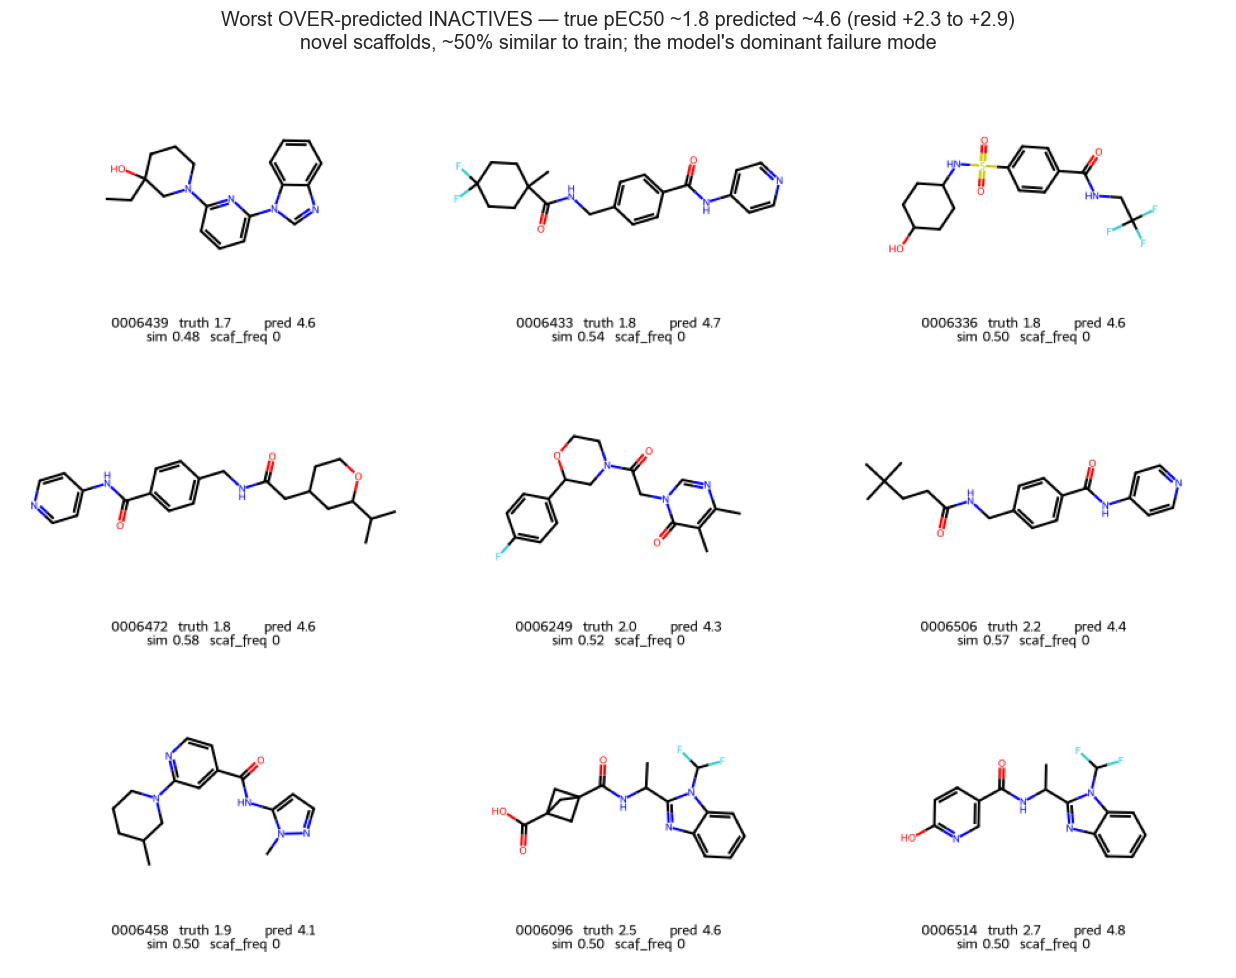

In [11]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io

def grid_png(sub, title):
    mols, legs = [], []
    for _, r in sub.iterrows():
        m = Chem.MolFromSmiles(r["smiles"])
        if m is None: continue
        mols.append(m)
        legs.append(f"{r['name'].replace('OADMET-','')}  truth {r['truth']:.1f}→pred {r['consensus_pred']:.1f}\n"
                    f"sim {r['nn_sim_train']:.2f}  scaf_freq {int(r['scaf_train_freq'])}")
    d = rdMolDraw2D.MolDraw2DCairo(960, 720, 320, 240)
    d.drawOptions().legendFontSize = 16
    d.DrawMolecules(mols, legends=legs)
    d.FinishDrawing()
    img = Image.open(io.BytesIO(d.GetDrawingText()))
    fig, ax = plt.subplots(figsize=(12, 9))
    ax.imshow(img); ax.axis("off")
    ax.set_title(title, fontsize=13)
    plt.tight_layout(); plt.show()

over_draw = cu.merge(cu, how="left")  # noop to keep smiles col present
over_draw = cu.sort_values("consensus_resid", ascending=False).head(9)
grid_png(over_draw,
         "Worst OVER-predicted INACTIVES — true pEC50 ~1.8 predicted ~4.6 (resid +2.3 to +2.9)\n"
         "novel scaffolds, ~50% similar to train; the model's dominant failure mode")

## Figure 9 -- Worst under-predicted actives (the hits we demoted), drawn
The mirror image: the 9 most under-predicted true-actives — real hits the model
pushed down toward the middle. Smaller residuals than the over-prediction side,
consistent with the 2.3x asymmetry, but these are the **missed hits** a screening
campaign would never follow up.

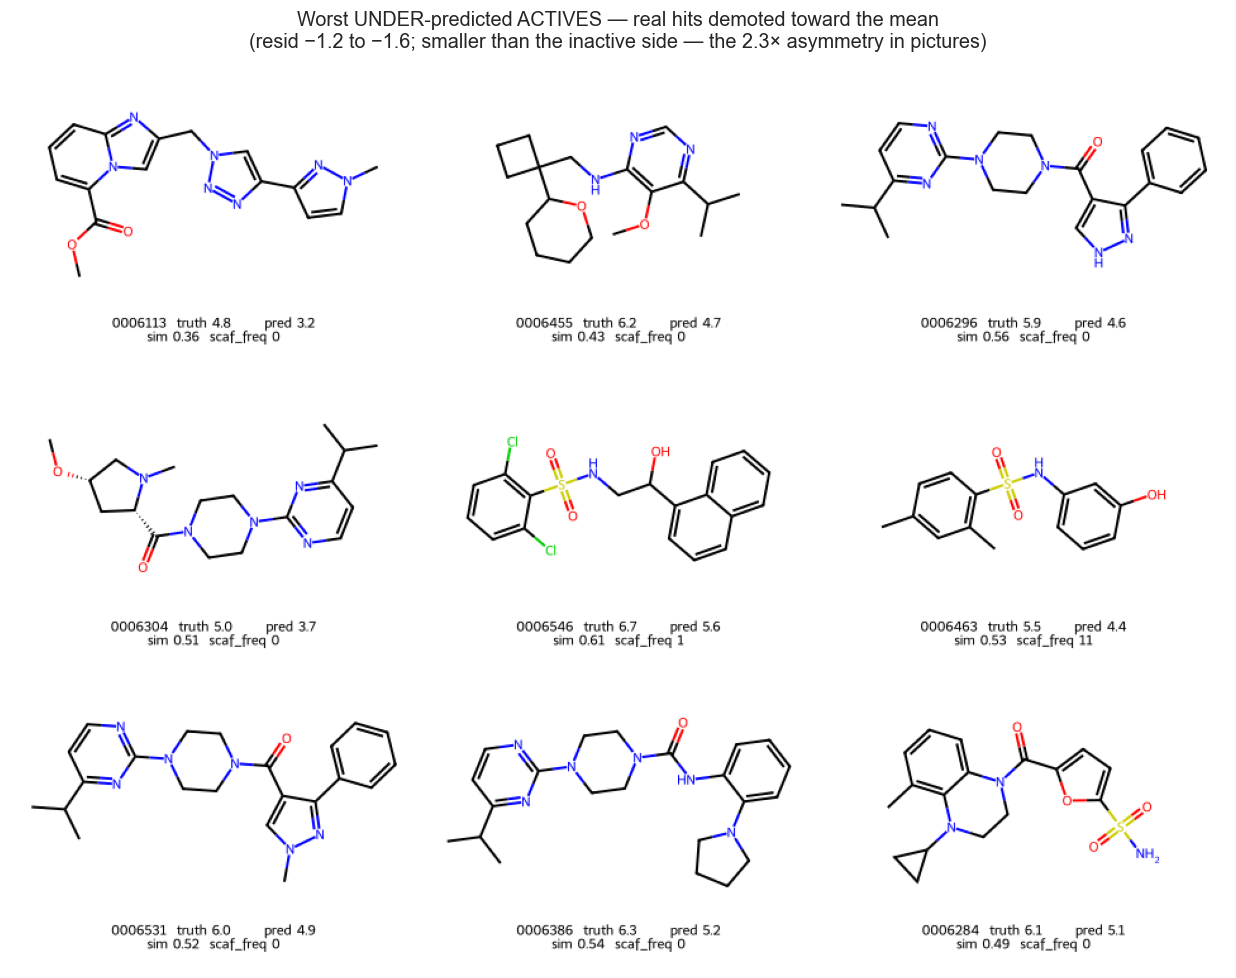

In [12]:
under_draw = cu.sort_values("consensus_resid").head(9)
grid_png(under_draw,
         "Worst UNDER-predicted ACTIVES — real hits demoted toward the mean\n"
         "(resid −1.2 to −1.6; smaller than the inactive side — the 2.3× asymmetry in pictures)")

## Figure 10 -- Where the asymmetry comes from: train activity distribution
Why is the low tail worse than the high tail? Because the **training set itself**
is heavily concentrated in the 4–5.5 band, with thin tails on *both* ends. A
model fit to that distribution regresses everything toward 4–5; the further a
truth is from that mass, the bigger the pull. Here we overlay the **train pEC50
histogram** with the **unblind truth** and the **unblind consensus prediction**.
The prediction distribution is a narrow spike inside the train mass — it has
inherited train's center and refuses its tails.

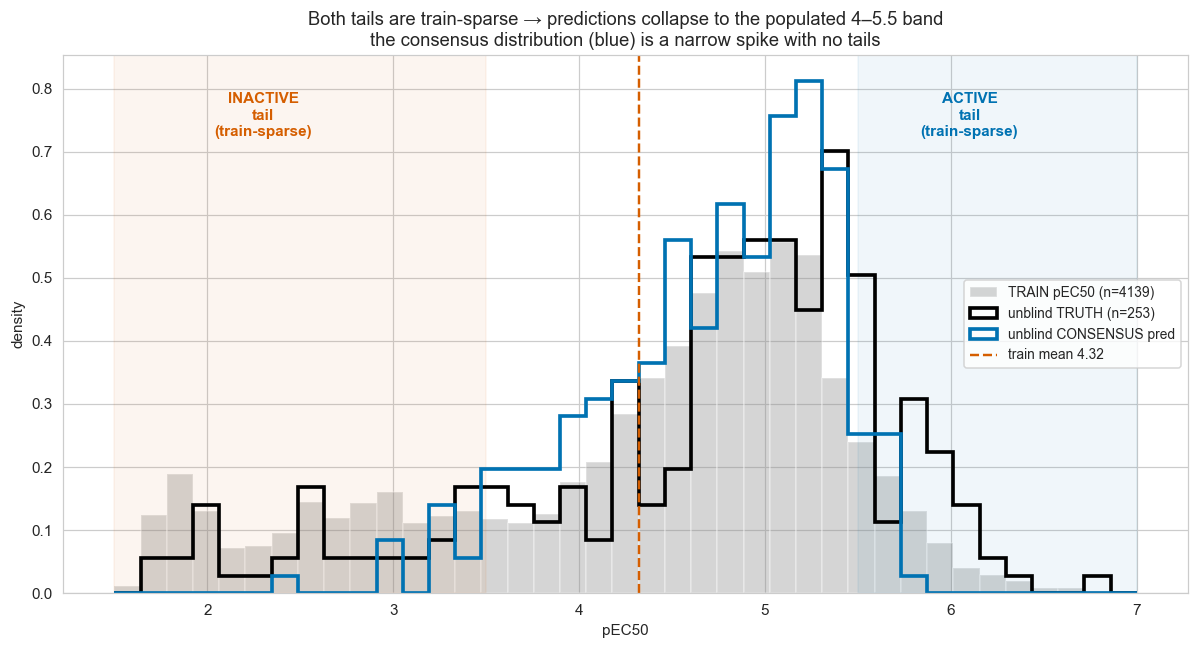

train pEC50: mean 4.32 std 1.12 | frac<3.5 0.233 | frac>=5.5 0.092


In [13]:
train_y = np.load(PM+"/pm_train_y.npy")
fig, ax = plt.subplots(figsize=(11, 6))
bins = np.linspace(1.5, 7.0, 40)
ax.hist(train_y, bins=bins, density=True, alpha=0.35, color="#888888", label=f"TRAIN pEC50 (n={len(train_y)})")
ax.hist(truth,   bins=bins, density=True, histtype="step", lw=2.4, color="k", label=f"unblind TRUTH (n=253)")
ax.hist(cp,      bins=bins, density=True, histtype="step", lw=2.4, color="#0072B2", label="unblind CONSENSUS pred")
ax.axvspan(1.5,3.5, color=C_LOW, alpha=0.06); ax.axvspan(5.5,7.0, color=C_HIGH, alpha=0.06)
ax.axvline(train_y.mean(), color="#D55E00", ls="--", lw=1.6, label=f"train mean {train_y.mean():.2f}")
ax.text(2.3, ax.get_ylim()[1]*0.85, "INACTIVE\ntail\n(train-sparse)", color=C_LOW, ha="center", fontsize=10, fontweight="bold")
ax.text(6.1, ax.get_ylim()[1]*0.85, "ACTIVE\ntail\n(train-sparse)", color=C_HIGH, ha="center", fontsize=10, fontweight="bold")
ax.set_xlabel("pEC50"); ax.set_ylabel("density")
ax.set_title("Both tails are train-sparse → predictions collapse to the populated 4–5.5 band\n"
             "the consensus distribution (blue) is a narrow spike with no tails")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print("train pEC50: mean %.2f std %.2f | frac<3.5 %.3f | frac>=5.5 %.3f"
      % (train_y.mean(), train_y.std(), (train_y<3.5).mean(), (train_y>=5.5).mean()))

**Lesson.** The training distribution explains the asymmetry directly. Only a few
percent of train sits below 3.5 or above 5.5; the bulk is 4–5.5. A learner that
minimizes squared/abs error on that mass will hedge toward the center, and the
hedge is *longest* for the most extreme truths. The unblind truth (black) has fat
tails the consensus (blue) simply does not produce.

# Verdict — answering the user's two questions

**Q: Were we missing the LOW or the HIGH activity side?**
**A: We missed BOTH, but the LOW (inactive) side roughly 2.3× worse.**

| side | n | signed bias (pred−truth) | MAE | what happens |
|---|---|---|---|---|
| **LOW** (inactive, <3.5) | 37 | **+1.23** | **1.28** | dead compounds called moderately active |
| MID (3.5–5.5) | 174 | −0.07 | 0.35 | well-calibrated (this is where train lives) |
| **HIGH** (active, ≥5.5) | 42 | **−0.54** | 0.55 | real hits demoted toward the mean |

**Mechanistic read.** A single mechanism — **variance compression toward the
train-populated 4–5.5 band** — produces both biases, and it is **universal**:
100% of legit models over-predict inactives and 100% under-predict actives
(Fig 3). The asymmetry exists because train has sparse tails on *both* ends, but
the inactive end is both sparser and farther from the center, so the regression
pull is longer there (+2.3..+2.9 on the worst inactives vs −1.2..−1.6 on the
worst actives, Fig 7–9). The worst misses are **novel-scaffold compounds at
~0.5 Tanimoto to train**: the model interprets "half-similar to an active
chemotype" as "active," but new scaffolds break that inference (Fig 7).

**Phase-2 prescriptions implied by this axis.**
1. **Fix the inactive side first** — it is the larger error and the easier signal
   (true inactives are biologically unambiguous). A *selectivity / counter-assay
   or toxicity prior* that says "novel scaffold + no specific PXR pharmacophore ⇒
   push down" attacks the +1.23 directly. (`oof_nb390_pcs_iso`, the structure-3D
   best model, already implicitly does some of this — it leads the table.)
2. **Stop tuning blends on compressed predictors.** Every in-matrix model lives
   in the same bias quadrant; re-averaging them cannot escape it. The gain has to
   come from a **tail-aware, scaffold-aware** correction or from outside the train
   manifold (external scaffold-diverse data, abstention on novel scaffolds).
3. **Triage on soft thresholds, not nominal cutoffs.** Compression herds
   everything into 4–5; a hard 5.5 hit cutoff misses most hits (29% recall) while
   a 5.0 cutoff recovers ~90%. Rank-and-cut, do not threshold at the nominal line.
4. **Variance, not just scale.** Slope ≈ 0.98 but range is 64% of truth and
   r ≈ 0.70 — the problem is compressed *and* noisy, which is why a single scalar
   rank-stretch only recovers a few thousandths. Real gains need per-region,
   confidence-gated decompression.

In [14]:
# ---- collect key numbers for the structured return ----
KEY = dict(
    bias_low=float(bias["low"]), bias_mid=float(bias["mid"]), bias_high=float(bias["high"]),
    mae_low=float(mae["low"]), mae_mid=float(mae["mid"]), mae_high=float(mae["high"]),
    low_high_mae_ratio=float(mae["low"]/mae["high"]),
    frac_models_overpredict_low=float(frac_over_low),
    frac_models_underpredict_high=float(frac_under_high),
    hit_recall_best=float(hit_recall_best),
    hit_recall_consensus=float(hit_recall_consensus),
    inactive_recall_consensus=float(inactive_recall_consensus),
    compression_slope_pred_on_truth=float(b),
    consensus_pearson=float(corr),
)
import pprint; pprint.pprint({k: round(v,3) for k,v in KEY.items()})

{'bias_high': -0.543,
 'bias_low': 1.226,
 'bias_mid': -0.071,
 'compression_slope_pred_on_truth': 0.431,
 'consensus_pearson': 0.698,
 'frac_models_overpredict_low': 1.0,
 'frac_models_underpredict_high': 1.0,
 'hit_recall_best': 0.452,
 'hit_recall_consensus': 0.286,
 'inactive_recall_consensus': 0.216,
 'low_high_mae_ratio': 2.336,
 'mae_high': 0.547,
 'mae_low': 1.279,
 'mae_mid': 0.349}
